# Exploratory Data Analysis (EDA) and Feature Engineering

This notebook performs comprehensive exploratory data analysis and feature engineering for water level prediction.

## Contents:
1. Load and inspect merged data
2. Basic statistics and data quality checks
3. Distribution analysis
4. Temporal trends visualization
5. Correlation analysis
6. Feature engineering
7. Risk assessment


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully")


Libraries imported successfully


## 1. Load Merged Data

In [2]:
# Load hourly merged data
df_hourly = pd.read_csv('full_merged.csv')
df_hourly['measure_datetime'] = pd.to_datetime(df_hourly['measure_datetime'])
df_hourly.set_index('measure_datetime', inplace=True)

print(f"Hourly data shape: {df_hourly.shape}")
print(f"Date range: {df_hourly.index.min()} to {df_hourly.index.max()}")
print(f"\nColumns: {df_hourly.columns.tolist()}")

df_hourly.head()

Hourly data shape: (56232, 16)
Date range: 2019-01-01 00:00:00 to 2025-05-31 23:00:00

Columns: ['water_level', 'temperature_2m', 'rain', 'showers', 'cloud_cover', 'relative_humidity_2m', 'dew_point_2m', 'precipitation', 'weather_code', 'pressure_msl', 'surface_pressure', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'et0_fao_evapotranspiration', 'river_discharge']


,water_level,temperature_2m,rain,showers,cloud_cover,relative_humidity_2m,dew_point_2m,precipitation,weather_code,pressure_msl,surface_pressure,wind_speed_10m,wind_direction_10m,wind_gusts_10m,et0_fao_evapotranspiration,river_discharge
measure_datetime,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,0.621667,23.5,0.0,0.0,2,65,16.6,0.0,0,1017.1,1017.0,6.9,43,11.2,0.03,1131.400000
2019-01-01 01:00:00,0.723333,22.7,0.0,0.0,1,68,16.4,0.0,0,1016.7,1016.6,6.6,22,10.8,0.02,1131.727083
2019-01-01 02:00:00,0.713333,22.0,0.0,0.0,2,75,17.3,0.0,0,1016.5,1016.4,6.0,25,10.4,0.01,1132.054167
2019-01-01 03:00:00,0.695000,21.4,0.0,0.0,2,80,17.8,0.0,0,1016.1,1016.0,5.3,28,9.4,0.00,1132.381250
2019-01-01 04:00:00,0.633333,20.7,0.0,0.0,1,86,18.3,0.0,0,1015.8,1015.7,7.2,18,8.6,0.00,1132.708333


In [3]:
# Load daily merged data
df_daily = pd.read_csv('full_merged_daily.csv')
df_daily['measure_datetime'] = pd.to_datetime(df_daily['measure_datetime'])
df_daily.set_index('measure_datetime', inplace=True)

print(f"Daily data shape: {df_daily.shape}")
print(f"Date range: {df_daily.index.min()} to {df_daily.index.max()}")

df_daily.head()

Daily data shape: (2343, 18)
Date range: 2019-01-01 00:00:00 to 2025-05-31 00:00:00


,water_level,temperature_2m,rain,showers,cloud_cover,relative_humidity_2m,dew_point_2m,precipitation,weather_code,pressure_msl,surface_pressure,wind_speed_10m,wind_direction_10m,wind_gusts_10m,et0_fao_evapotranspiration,river_discharge,water_level_pct,risk_level
measure_datetime,,,,,,,,,,,,,,,,,,
2019-01-01,0.647222,24.200000,0.000000,0.0,55.875000,65.875000,17.191667,0.000000,1.666667,1016.187500,1016.087500,6.916667,70.333333,14.545833,0.169583,1135.161458,91.524675,High Risk
2019-01-02,0.692986,24.195833,0.000000,0.0,86.708333,63.041667,16.504167,0.000000,2.625000,1015.558333,1015.458333,7.358333,138.000000,15.433333,0.172917,1141.770417,91.780898,High Risk
2019-01-03,0.515486,25.362500,0.000000,0.0,83.416667,56.916667,16.162500,0.000000,2.583333,1015.370833,1015.270833,12.512500,183.375000,23.650000,0.189167,1141.989583,90.787112,High Risk
2019-01-04,0.797917,24.812500,0.125000,0.0,99.958333,70.916667,19.008333,0.125000,11.666667,1014.475000,1014.375000,8.550000,93.333333,16.150000,0.099583,1050.479583,92.368382,High Risk
2019-01-05,1.155833,24.516667,0.179167,0.0,100.000000,75.375000,19.812500,0.179167,15.666667,1013.595833,1013.495833,11.662500,211.250000,22.833333,0.085833,809.348750,94.372282,High Risk


## 2. Basic Statistics and Data Quality

In [4]:
# Descriptive statistics for hourly data
print("=== HOURLY DATA DESCRIPTIVE STATISTICS ===")
df_hourly.describe()

=== HOURLY DATA DESCRIPTIVE STATISTICS ===


,water_level,temperature_2m,rain,showers,cloud_cover,relative_humidity_2m,dew_point_2m,precipitation,weather_code,pressure_msl,surface_pressure,wind_speed_10m,wind_direction_10m,wind_gusts_10m,et0_fao_evapotranspiration,river_discharge
count,56232.000000,56232.000000,56232.000000,56232.0,56232.000000,56232.000000,56232.000000,56232.000000,56232.000000,56232.000000,56232.000000,56232.000000,56232.000000,56232.000000,56232.000000,56232.000000
mean,0.390225,28.193141,0.179494,0.0,69.235524,74.350494,22.830203,0.179494,12.820102,1009.349577,1009.249577,9.426142,180.359386,20.077043,0.183186,1223.418451
std,0.690438,2.980016,0.797400,0.0,36.774707,14.614136,3.056060,0.797400,21.162602,3.050357,3.050357,4.546150,91.862950,9.288079,0.219675,1467.445569
min,-9.376667,15.400000,0.000000,0.0,0.000000,17.000000,5.700000,0.000000,0.000000,999.200000,999.100000,0.000000,1.000000,0.700000,0.000000,0.000000
25%,-0.086667,26.300000,0.000000,0.0,35.000000,65.000000,22.000000,0.000000,1.000000,1007.200000,1007.100000,5.900000,116.000000,12.600000,0.010000,0.181979
50%,0.508333,28.100000,0.000000,0.0,91.000000,77.000000,23.900000,0.000000,3.000000,1009.200000,1009.100000,8.800000,188.000000,19.100000,0.060000,817.475417
75%,0.901667,30.200000,0.000000,0.0,100.000000,86.000000,24.800000,0.000000,3.000000,1011.400000,1011.300000,12.400000,238.000000,26.300000,0.340000,1718.802500
max,4.853333,38.700000,22.100000,0.0,100.000000,100.000000,28.100000,22.100000,65.000000,1020.700000,1020.600000,29.300000,360.000000,63.400000,0.850000,7463.490000


In [5]:
# Check for missing values
print("=== MISSING VALUES ===")
missing_hourly = df_hourly.isnull().sum()
print("\nHourly data:")
print(missing_hourly[missing_hourly > 0] if missing_hourly.sum() > 0 else "No missing values")

missing_daily = df_daily.isnull().sum()
print("\nDaily data:")
print(missing_daily[missing_daily > 0] if missing_daily.sum() > 0 else "No missing values")

=== MISSING VALUES ===

Hourly data:
No missing values

Daily data:
No missing values


In [6]:
# Data types and memory usage
print("=== DATA INFO ===")
df_hourly.info()

=== DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 56232 entries, 2019-01-01 00:00:00 to 2025-05-31 23:00:00
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   water_level                 56232 non-null  float64
 1   temperature_2m              56232 non-null  float64
 2   rain                        56232 non-null  float64
 3   showers                     56232 non-null  float64
 4   cloud_cover                 56232 non-null  int64  
 5   relative_humidity_2m        56232 non-null  int64  
 6   dew_point_2m                56232 non-null  float64
 7   precipitation               56232 non-null  float64
 8   weather_code                56232 non-null  int64  
 9   pressure_msl                56232 non-null  float64
 10  surface_pressure            56232 non-null  float64
 11  wind_speed_10m              56232 non-null  float64
 12  wind_direction_10m          56232 n

## 3. Distribution Analysis

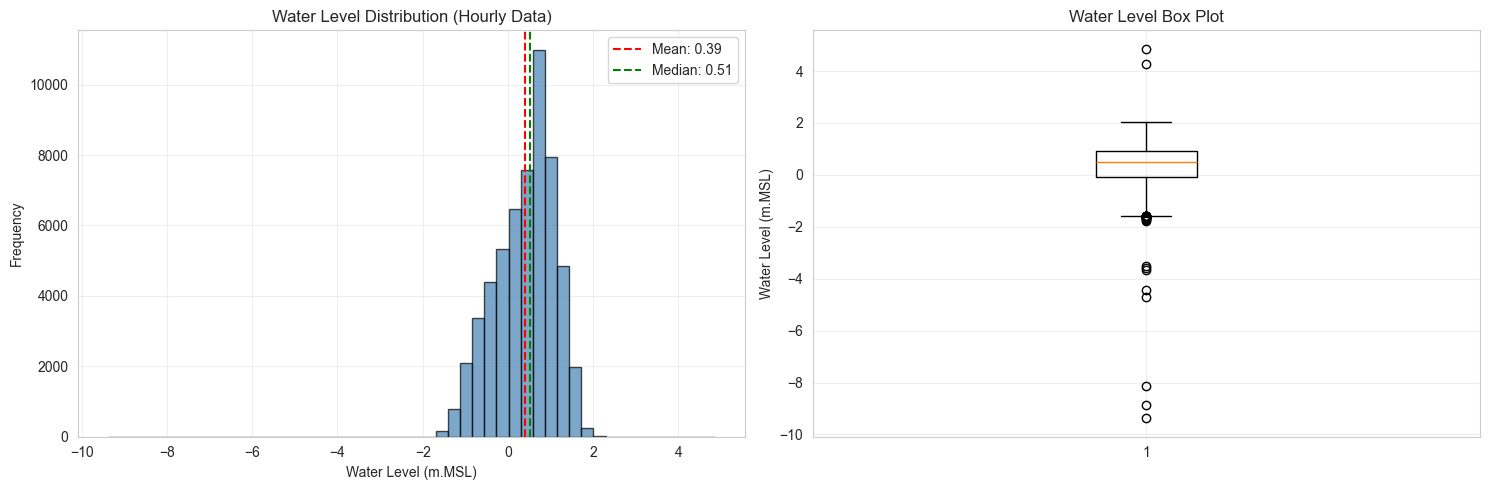


=== NORMALITY TEST (Shapiro-Wilk) ===
Test Statistic: 0.974560
P-value: 0.000000
Distribution is not normal at 95% confidence level


In [7]:
# Water level distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df_hourly['water_level'], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Water Level (m.MSL)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Water Level Distribution (Hourly Data)')
axes[0].axvline(df_hourly['water_level'].mean(), color='red', linestyle='--', 
                label=f"Mean: {df_hourly['water_level'].mean():.2f}")
axes[0].axvline(df_hourly['water_level'].median(), color='green', linestyle='--', 
                label=f"Median: {df_hourly['water_level'].median():.2f}")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(df_hourly['water_level'], vert=True)
axes[1].set_ylabel('Water Level (m.MSL)')
axes[1].set_title('Water Level Box Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical tests
print("\n=== NORMALITY TEST (Shapiro-Wilk) ===")
stat, p_value = stats.shapiro(df_hourly['water_level'].sample(min(5000, len(df_hourly))))
print(f"Test Statistic: {stat:.6f}")
print(f"P-value: {p_value:.6f}")
print(f"Distribution is {'normal' if p_value > 0.05 else 'not normal'} at 95% confidence level")

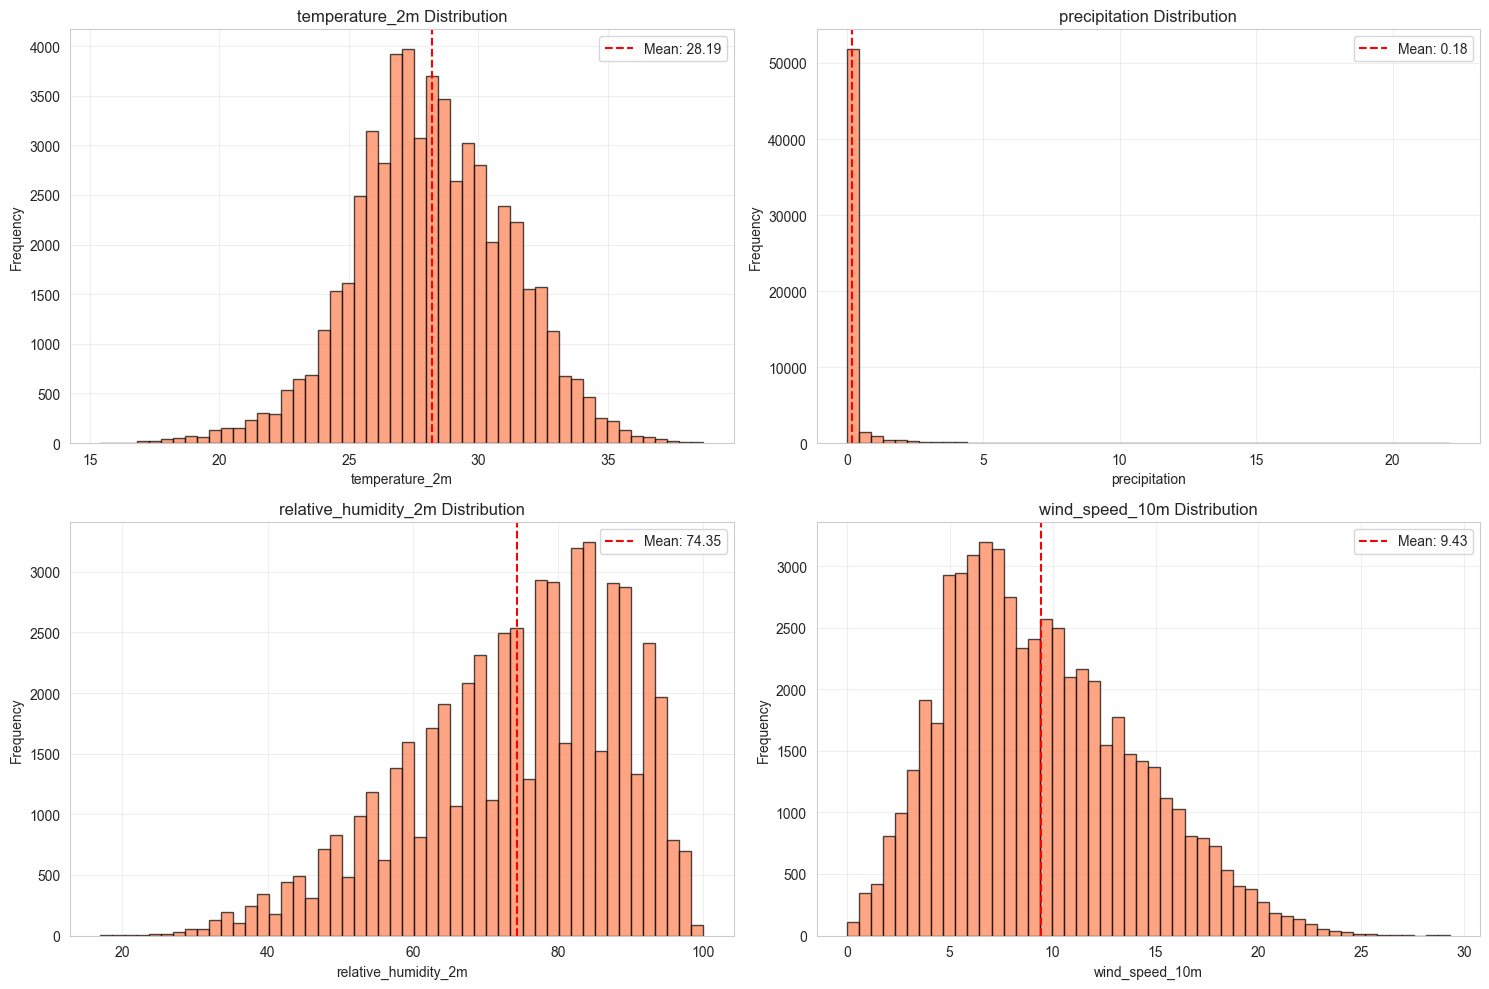

In [8]:
# Distribution of key weather variables
weather_vars = ['temperature_2m', 'precipitation', 'relative_humidity_2m', 'wind_speed_10m']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, var in enumerate(weather_vars):
    axes[i].hist(df_hourly[var], bins=50, alpha=0.7, color='coral', edgecolor='black')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'{var} Distribution')
    axes[i].axvline(df_hourly[var].mean(), color='red', linestyle='--', 
                     label=f"Mean: {df_hourly[var].mean():.2f}")
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Temporal Trends Visualization

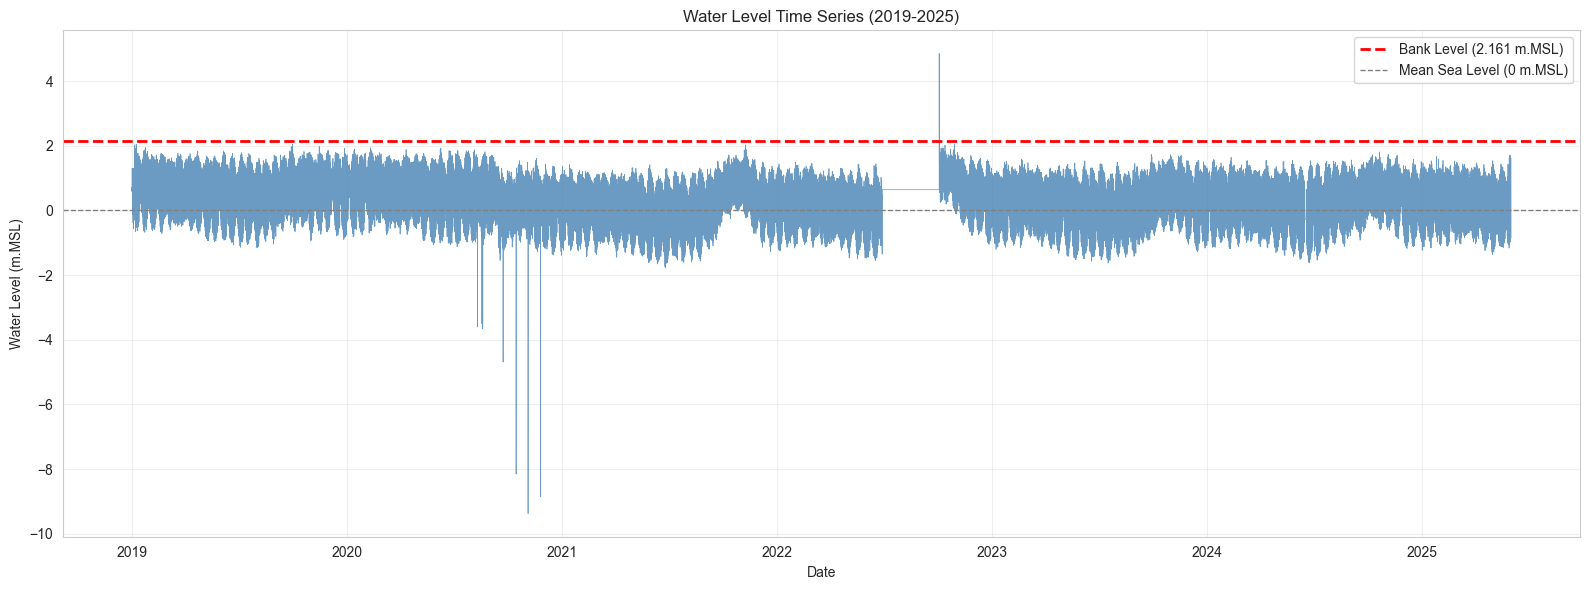

In [9]:
# Time series plot of water level
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df_hourly.index, df_hourly['water_level'], color='steelblue', linewidth=0.5, alpha=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Water Level (m.MSL)')
ax.set_title('Water Level Time Series (2019-2025)')
ax.grid(True, alpha=0.3)

# Add horizontal lines for bank level and bed level
BANK_LEVEL = 2.161
BED_LEVEL = -15.70
ax.axhline(BANK_LEVEL, color='red', linestyle='--', linewidth=2, label=f'Bank Level ({BANK_LEVEL} m.MSL)')
ax.axhline(0, color='gray', linestyle='--', linewidth=1, label='Mean Sea Level (0 m.MSL)')
ax.legend()

plt.tight_layout()
plt.show()

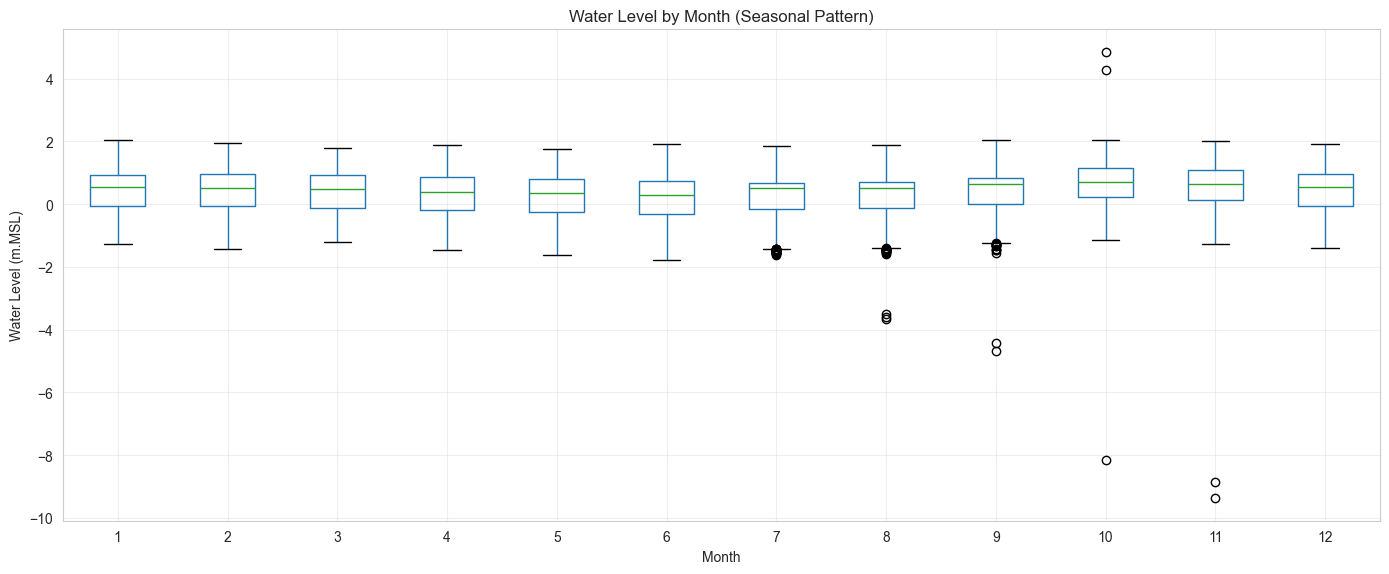


=== AVERAGE WATER LEVEL BY MONTH ===
month
1     0.429040
2     0.436247
3     0.388891
4     0.324879
5     0.257122
6     0.184323
7     0.291023
8     0.320256
9     0.419318
10    0.667127
11    0.569368
12    0.416581
Name: water_level, dtype: float64


In [10]:
# Seasonal patterns - Monthly boxplot
df_hourly['month'] = df_hourly.index.month
df_hourly['year'] = df_hourly.index.year

fig, ax = plt.subplots(figsize=(14, 6))
df_hourly.boxplot(column='water_level', by='month', ax=ax)
ax.set_xlabel('Month')
ax.set_ylabel('Water Level (m.MSL)')
ax.set_title('Water Level by Month (Seasonal Pattern)')
plt.suptitle('')  # Remove default title
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Monthly average
monthly_avg = df_hourly.groupby('month')['water_level'].mean()
print("\n=== AVERAGE WATER LEVEL BY MONTH ===")
print(monthly_avg)

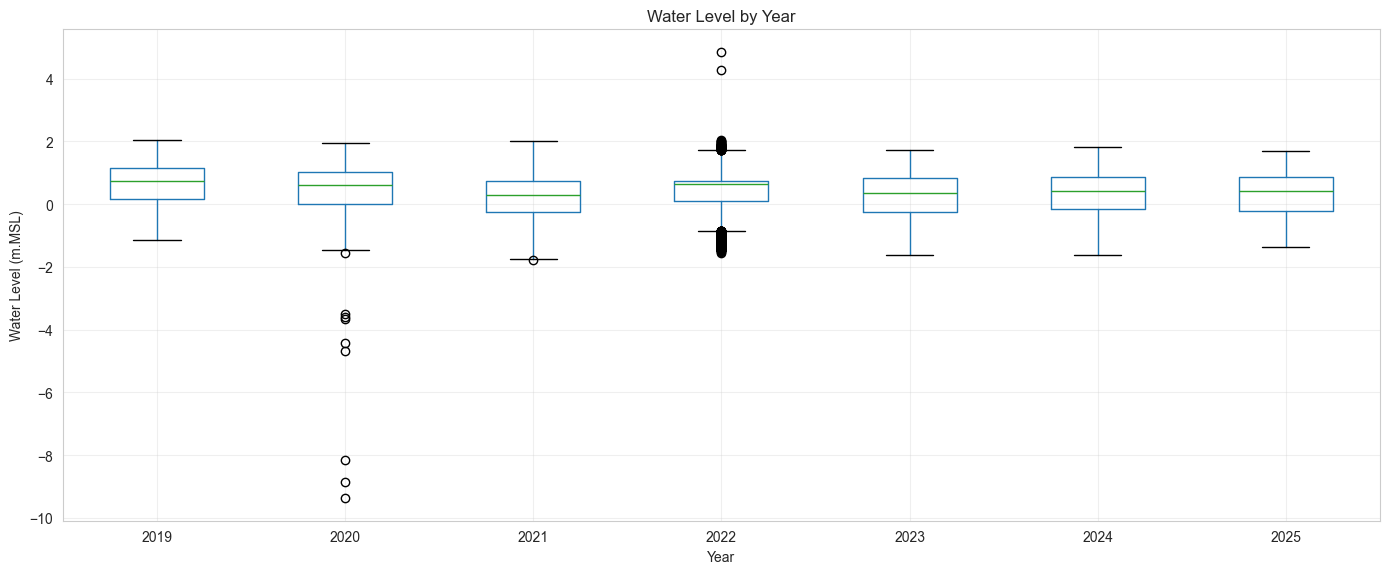


=== WATER LEVEL STATISTICS BY YEAR ===
          mean       std       min       max
year                                        
2019  0.636641  0.653069 -1.155000  2.045000
2020  0.496487  0.714866 -9.376667  1.933333
2021  0.204456  0.689435 -1.778333  2.021667
2022  0.438385  0.620125 -1.548333  4.853333
2023  0.262451  0.692713 -1.628333  1.730000
2024  0.334254  0.678562 -1.625000  1.810000
2025  0.314177  0.676383 -1.360000  1.705000


In [11]:
# Yearly trends
fig, ax = plt.subplots(figsize=(14, 6))
df_hourly.boxplot(column='water_level', by='year', ax=ax)
ax.set_xlabel('Year')
ax.set_ylabel('Water Level (m.MSL)')
ax.set_title('Water Level by Year')
plt.suptitle('')  # Remove default title
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Yearly statistics
yearly_stats = df_hourly.groupby('year')['water_level'].agg(['mean', 'std', 'min', 'max'])
print("\n=== WATER LEVEL STATISTICS BY YEAR ===")
print(yearly_stats)

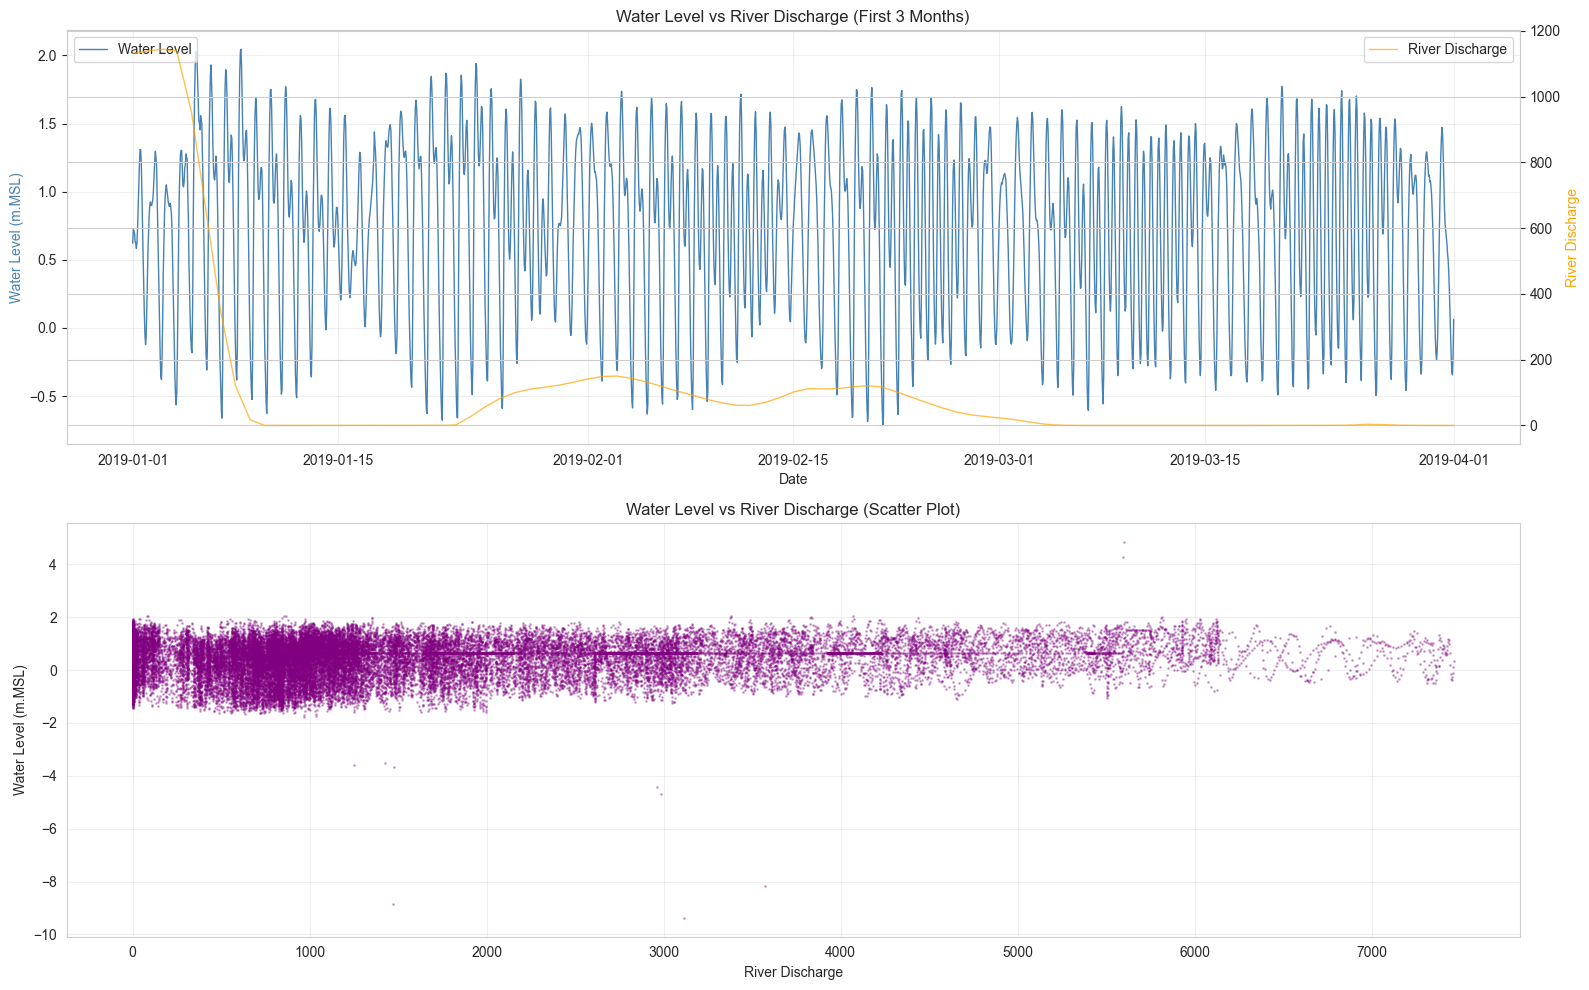

In [12]:
# Water level vs River discharge
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Time series comparison
ax1 = axes[0]
ax2 = ax1.twinx()

# Plot on subset for clarity (e.g., first 3 months)
subset = df_hourly.iloc[:2160]  # ~3 months of hourly data
ax1.plot(subset.index, subset['water_level'], color='steelblue', label='Water Level', linewidth=1)
ax2.plot(subset.index, subset['river_discharge'], color='orange', label='River Discharge', linewidth=1, alpha=0.7)

ax1.set_xlabel('Date')
ax1.set_ylabel('Water Level (m.MSL)', color='steelblue')
ax2.set_ylabel('River Discharge', color='orange')
ax1.set_title('Water Level vs River Discharge (First 3 Months)')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Scatter plot
axes[1].scatter(df_hourly['river_discharge'], df_hourly['water_level'], alpha=0.3, s=1, color='purple')
axes[1].set_xlabel('River Discharge')
axes[1].set_ylabel('Water Level (m.MSL)')
axes[1].set_title('Water Level vs River Discharge (Scatter Plot)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Correlation Analysis

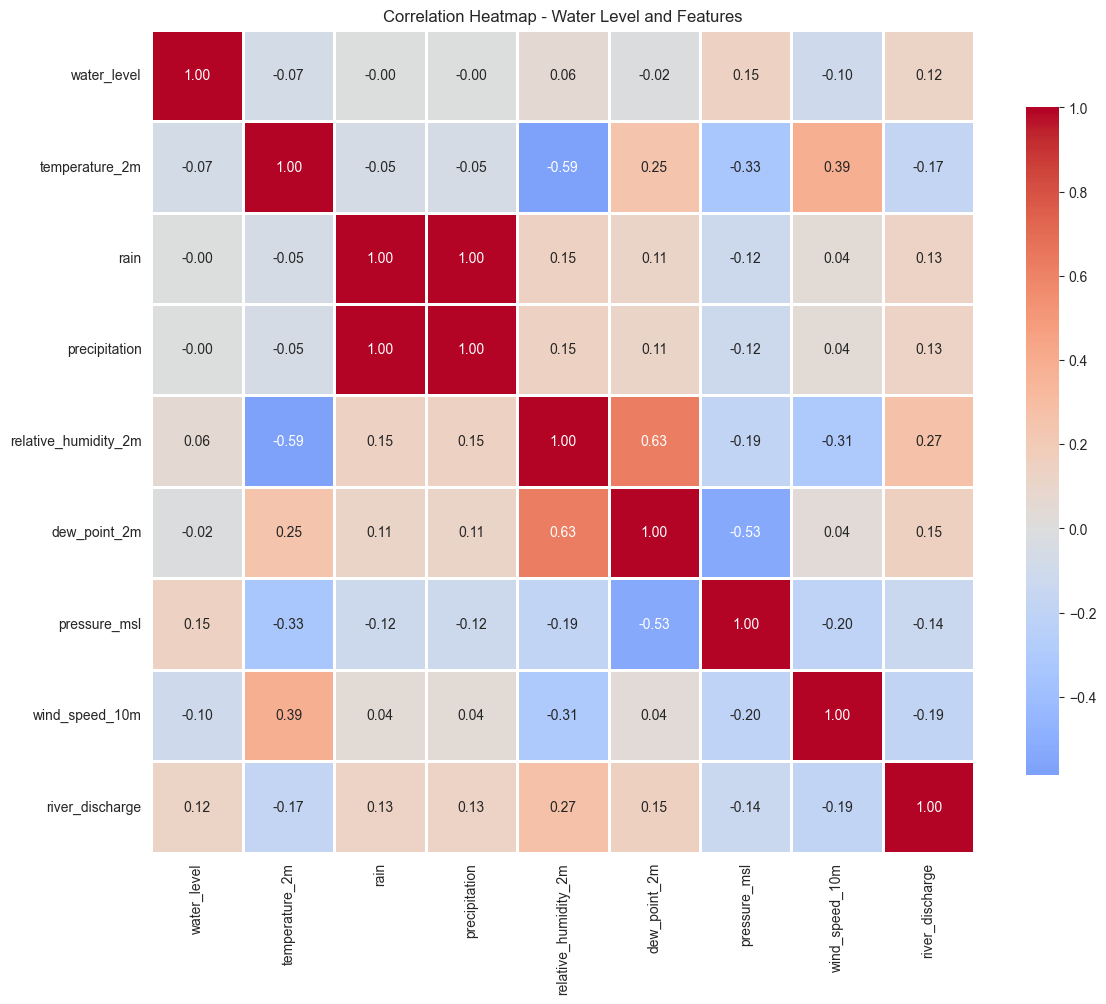


=== TOP CORRELATIONS WITH WATER LEVEL ===
water_level             1.000000
pressure_msl            0.149144
river_discharge         0.122194
relative_humidity_2m    0.055032
rain                   -0.003490
precipitation          -0.003490
dew_point_2m           -0.015407
temperature_2m         -0.073126
wind_speed_10m         -0.102882
Name: water_level, dtype: float64


In [13]:
# Correlation matrix
correlation_matrix = df_hourly[[
    'water_level', 'temperature_2m', 'rain', 'precipitation', 
    'relative_humidity_2m', 'dew_point_2m', 'pressure_msl', 
    'wind_speed_10m', 'river_discharge'
]].corr()

# Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.2f', ax=ax)
ax.set_title('Correlation Heatmap - Water Level and Features')
plt.tight_layout()
plt.show()

# Top correlations with water level
print("\n=== TOP CORRELATIONS WITH WATER LEVEL ===")
water_level_corr = correlation_matrix['water_level'].sort_values(ascending=False)
print(water_level_corr)

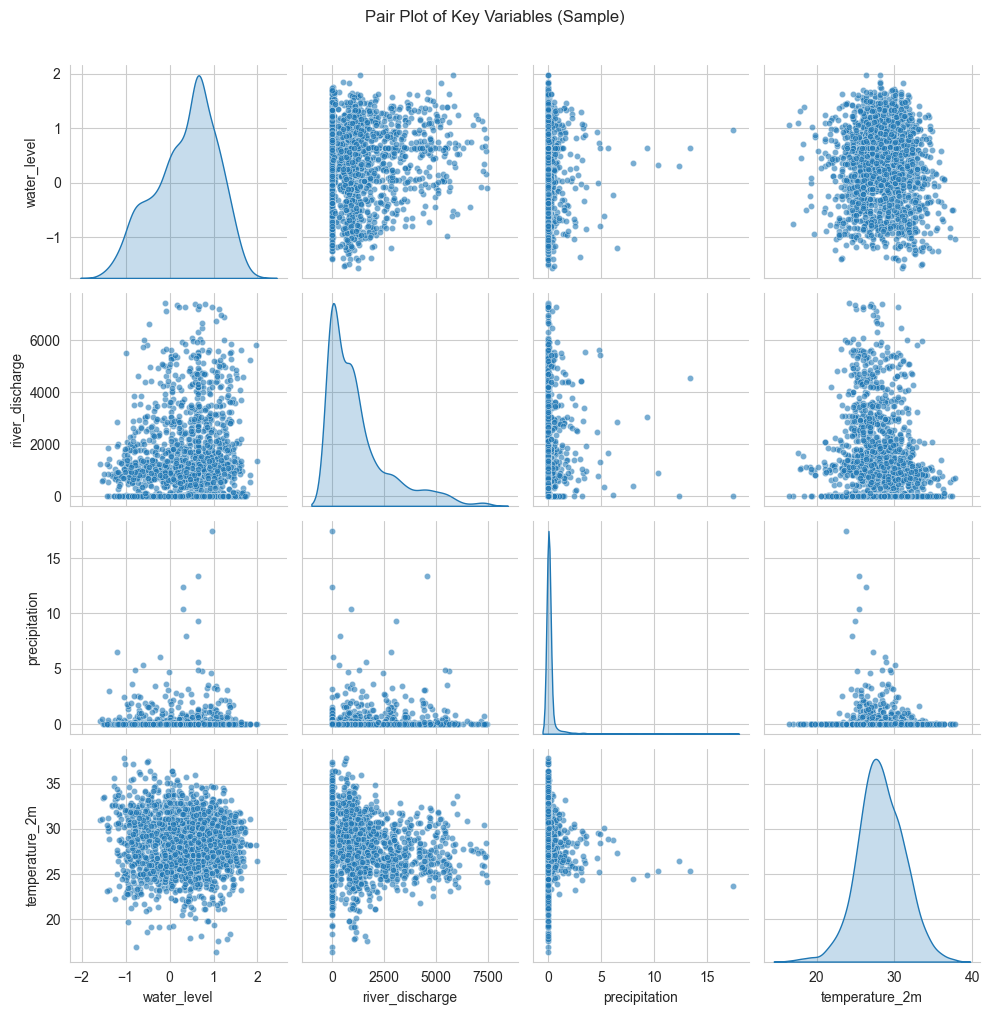

In [14]:
# Pair plot for key variables (using sample for performance)
sample_data = df_hourly[[
    'water_level', 'river_discharge', 'precipitation', 'temperature_2m'
]].sample(n=min(2000, len(df_hourly)), random_state=42)

sns.pairplot(sample_data, diag_kind='kde', plot_kws={'alpha': 0.6, 's': 20})
plt.suptitle('Pair Plot of Key Variables (Sample)', y=1.01)
plt.tight_layout()
plt.show()

## 6. Feature Engineering

Creating temporal features, lag features, rolling statistics, and other engineered features to improve model performance.

In [15]:
# Feature Engineering for hourly data
print("=== FEATURE ENGINEERING FOR HOURLY DATA ===")
print(f"Original hourly data shape: {df_hourly.shape}")

# Drop temporary columns if they exist
df_hourly = df_hourly.drop(columns=['month', 'year'], errors='ignore')

# 1. Lag Features for water level (autoregressive features)
print("\nAdding lag features...")
for lag in [1, 2, 3, 6, 12, 24]:
    df_hourly[f'water_level_lag_{lag}'] = df_hourly['water_level'].shift(lag)

# 2. Rolling Statistics for water level
print("Adding rolling statistics...")
for window in [6, 12, 24]:
    df_hourly[f'water_level_rolling_mean_{window}'] = df_hourly['water_level'].rolling(window=window).mean()
    df_hourly[f'water_level_rolling_std_{window}'] = df_hourly['water_level'].rolling(window=window).std()
    df_hourly[f'water_level_rolling_min_{window}'] = df_hourly['water_level'].rolling(window=window).min()
    df_hourly[f'water_level_rolling_max_{window}'] = df_hourly['water_level'].rolling(window=window).max()

# 3. Rolling Statistics for key weather features
print("Adding weather feature rolling statistics...")
for col in ['rain', 'precipitation', 'river_discharge', 'temperature_2m']:
    if col in df_hourly.columns:
        df_hourly[f'{col}_rolling_mean_6'] = df_hourly[col].rolling(window=6).mean()
        df_hourly[f'{col}_rolling_mean_12'] = df_hourly[col].rolling(window=12).mean()

# 4. Difference features (rate of change)
print("Adding difference features...")
df_hourly['water_level_diff_1'] = df_hourly['water_level'].diff(1)
df_hourly['water_level_diff_24'] = df_hourly['water_level'].diff(24)

# 5. Water Level Risk Assessment (Station CPY015 - Krungthep Bridge)
print("Adding risk assessment features...")

# Station parameters (m.MSL - meters relative to Mean Sea Level)
BANK_LEVEL = 2.161  # Top of riverbank
BED_LEVEL = -15.70  # River bed level
TOTAL_CAPACITY = BANK_LEVEL - BED_LEVEL  # Total vertical capacity

# Calculate water level percentage
df_hourly['water_level_pct'] = ((df_hourly['water_level'] - BED_LEVEL) / TOTAL_CAPACITY) * 100

# Determine risk level based on water level percentage
def determine_risk_level(water_level_pct):
    if water_level_pct >= 70:
        return 'High Risk'
    elif water_level_pct >= 30:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df_hourly['risk_level'] = df_hourly['water_level_pct'].apply(determine_risk_level)

# Drop rows with NaN values from feature engineering
df_hourly_featured = df_hourly.dropna()

print(f"\nAfter feature engineering: {df_hourly_featured.shape}")
print(f"New features added: {df_hourly_featured.shape[1] - 16}")  # 16 was original count
print(f"\nRisk Level Distribution:")
print(df_hourly_featured['risk_level'].value_counts())

# Save featured hourly data
df_hourly_featured.to_csv('full_merged_featured.csv')
print("\nFeatured hourly data saved to: full_merged_featured.csv")

# Display first few rows
df_hourly_featured.head()

=== FEATURE ENGINEERING FOR HOURLY DATA ===
Original hourly data shape: (56232, 18)

Adding lag features...
Adding rolling statistics...
Adding weather feature rolling statistics...
Adding difference features...
Adding risk assessment features...

After feature engineering: (56208, 46)
New features added: 30

Risk Level Distribution:
risk_level
High Risk      56200
Medium Risk        8
Name: count, dtype: int64

Featured hourly data saved to: full_merged_featured.csv


,water_level,temperature_2m,rain,showers,cloud_cover,relative_humidity_2m,dew_point_2m,precipitation,weather_code,pressure_msl,...,precipitation_rolling_mean_6,precipitation_rolling_mean_12,river_discharge_rolling_mean_6,river_discharge_rolling_mean_12,temperature_2m_rolling_mean_6,temperature_2m_rolling_mean_12,water_level_diff_1,water_level_diff_24,water_level_pct,risk_level
measure_datetime,,,,,,,,,,,,,,,,,,,,,
2019-01-02 00:00:00,0.346667,22.4,0.0,0.0,100,66,15.8,0.0,3,1016.3,...,0.0,0.0,1138.432292,1137.451042,24.133333,25.891667,0.216667,-0.275000,89.841927,High Risk
2019-01-02 01:00:00,0.581667,21.9,0.0,0.0,100,72,16.7,0.0,3,1016.6,...,0.0,0.0,1138.741389,1137.769132,23.633333,25.425000,0.235000,-0.141667,91.157643,High Risk
2019-01-02 02:00:00,0.708333,22.7,0.0,0.0,99,67,16.2,0.0,3,1016.1,...,0.0,0.0,1139.032500,1138.078229,23.200000,24.975000,0.126667,-0.005000,91.866823,High Risk
2019-01-02 03:00:00,0.836667,21.2,0.0,0.0,96,73,16.2,0.0,3,1015.3,...,0.0,0.0,1139.305625,1138.378333,22.616667,24.375000,0.128333,0.141667,92.585335,High Risk
2019-01-02 04:00:00,0.903333,20.2,0.0,0.0,98,78,16.1,0.0,3,1015.2,...,0.0,0.0,1139.560764,1138.669444,21.983333,23.700000,0.066667,0.270000,92.958588,High Risk


In [16]:
# Feature Engineering for daily data
print("=== FEATURE ENGINEERING FOR DAILY DATA ===")
print(f"Original daily data shape: {df_daily.shape}")

# 1. Lag Features for water level
print("\nAdding lag features...")
for lag in [1, 2, 3, 7, 14]:
    df_daily[f'water_level_lag_{lag}'] = df_daily['water_level'].shift(lag)

# 2. Rolling Statistics for water level
print("Adding rolling statistics...")
for window in [3, 7, 14]:
    df_daily[f'water_level_rolling_mean_{window}'] = df_daily['water_level'].rolling(window=window).mean()
    df_daily[f'water_level_rolling_std_{window}'] = df_daily['water_level'].rolling(window=window).std()
    df_daily[f'water_level_rolling_min_{window}'] = df_daily['water_level'].rolling(window=window).min()
    df_daily[f'water_level_rolling_max_{window}'] = df_daily['water_level'].rolling(window=window).max()

# 3. Rolling Statistics for key weather features
print("Adding weather feature rolling statistics...")
for col in ['rain', 'precipitation', 'river_discharge', 'temperature_2m']:
    if col in df_daily.columns:
        df_daily[f'{col}_rolling_mean_7'] = df_daily[col].rolling(window=7).mean()

# 4. Difference features
print("Adding difference features...")
df_daily['water_level_diff_1'] = df_daily['water_level'].diff(1)
df_daily['water_level_diff_7'] = df_daily['water_level'].diff(7)

# 5. Water Level Risk Assessment (Station CPY015 - Krungthep Bridge)
print("Adding risk assessment features...")

# Calculate water level percentage (if not already present)
if 'water_level_pct' not in df_daily.columns:
    df_daily['water_level_pct'] = ((df_daily['water_level'] - BED_LEVEL) / TOTAL_CAPACITY) * 100

# Determine risk level
if 'risk_level' not in df_daily.columns:
    df_daily['risk_level'] = df_daily['water_level_pct'].apply(determine_risk_level)

# Drop rows with NaN values
df_daily_featured = df_daily.dropna()

print(f"\nAfter feature engineering: {df_daily_featured.shape}")
print(f"New features added: {df_daily_featured.shape[1] - 18}")  # 18 was original count with risk columns
print(f"\nRisk Level Distribution:")
print(df_daily_featured['risk_level'].value_counts())

# Save featured daily data
df_daily_featured.to_csv('full_merged_daily_featured.csv')
print("\nFeatured daily data saved to: full_merged_daily_featured.csv")

# Display first few rows
df_daily_featured.head()

=== FEATURE ENGINEERING FOR DAILY DATA ===
Original daily data shape: (2343, 18)

Adding lag features...
Adding rolling statistics...
Adding weather feature rolling statistics...
Adding difference features...
Adding risk assessment features...

After feature engineering: (2329, 41)
New features added: 23

Risk Level Distribution:
risk_level
High Risk    2329
Name: count, dtype: int64

Featured daily data saved to: full_merged_daily_featured.csv


,water_level,temperature_2m,rain,showers,cloud_cover,relative_humidity_2m,dew_point_2m,precipitation,weather_code,pressure_msl,...,water_level_rolling_mean_14,water_level_rolling_std_14,water_level_rolling_min_14,water_level_rolling_max_14,rain_rolling_mean_7,precipitation_rolling_mean_7,river_discharge_rolling_mean_7,temperature_2m_rolling_mean_7,water_level_diff_1,water_level_diff_7
measure_datetime,,,,,,,,,,,,,,,,,,,,,
2019-01-15,0.705347,27.566667,0.200000,0.0,63.583333,80.541667,23.745833,0.200000,8.500000,1010.695833,...,0.800179,0.157916,0.515486,1.155833,0.062500,0.062500,1.233631,27.527381,-0.088958,-0.324583
2019-01-16,0.612778,27.087500,0.033333,0.0,34.791667,76.750000,22.429167,0.033333,5.125000,1011.133333,...,0.794449,0.163462,0.515486,1.155833,0.047619,0.047619,0.000000,27.554762,-0.092569,-0.147639
2019-01-17,0.750694,27.275000,0.012500,0.0,40.041667,69.041667,20.545833,0.012500,7.500000,1011.225000,...,0.811250,0.143446,0.612778,1.155833,0.045238,0.045238,0.000000,27.582143,0.137917,-0.034861
2019-01-18,0.912569,26.304167,0.000000,0.0,79.833333,60.458333,17.991667,0.000000,2.583333,1012.350000,...,0.819439,0.145879,0.612778,1.155833,0.042262,0.042262,0.000000,27.456548,0.161875,0.151597
2019-01-19,0.880000,26.333333,0.000000,0.0,48.958333,63.458333,18.666667,0.000000,1.458333,1012.033333,...,0.799737,0.111534,0.612778,1.029931,0.040476,0.040476,0.000000,27.244048,-0.032569,0.222986


## 7. Feature Importance Analysis

In [17]:
# List all engineered features
print("=== ENGINEERED FEATURES ===")
print(f"\nTotal features in hourly data: {df_hourly_featured.shape[1]}")
print(f"Total features in daily data: {df_daily_featured.shape[1]}")

print("\nHourly data columns:")
print(df_hourly_featured.columns.tolist())

print("\nDaily data columns:")
print(df_daily_featured.columns.tolist())

=== ENGINEERED FEATURES ===

Total features in hourly data: 46
Total features in daily data: 41

Hourly data columns:
['water_level', 'temperature_2m', 'rain', 'showers', 'cloud_cover', 'relative_humidity_2m', 'dew_point_2m', 'precipitation', 'weather_code', 'pressure_msl', 'surface_pressure', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'et0_fao_evapotranspiration', 'river_discharge', 'water_level_lag_1', 'water_level_lag_2', 'water_level_lag_3', 'water_level_lag_6', 'water_level_lag_12', 'water_level_lag_24', 'water_level_rolling_mean_6', 'water_level_rolling_std_6', 'water_level_rolling_min_6', 'water_level_rolling_max_6', 'water_level_rolling_mean_12', 'water_level_rolling_std_12', 'water_level_rolling_min_12', 'water_level_rolling_max_12', 'water_level_rolling_mean_24', 'water_level_rolling_std_24', 'water_level_rolling_min_24', 'water_level_rolling_max_24', 'rain_rolling_mean_6', 'rain_rolling_mean_12', 'precipitation_rolling_mean_6', 'precipitation_rolling_mean_12',

## 8. Risk Assessment Analysis

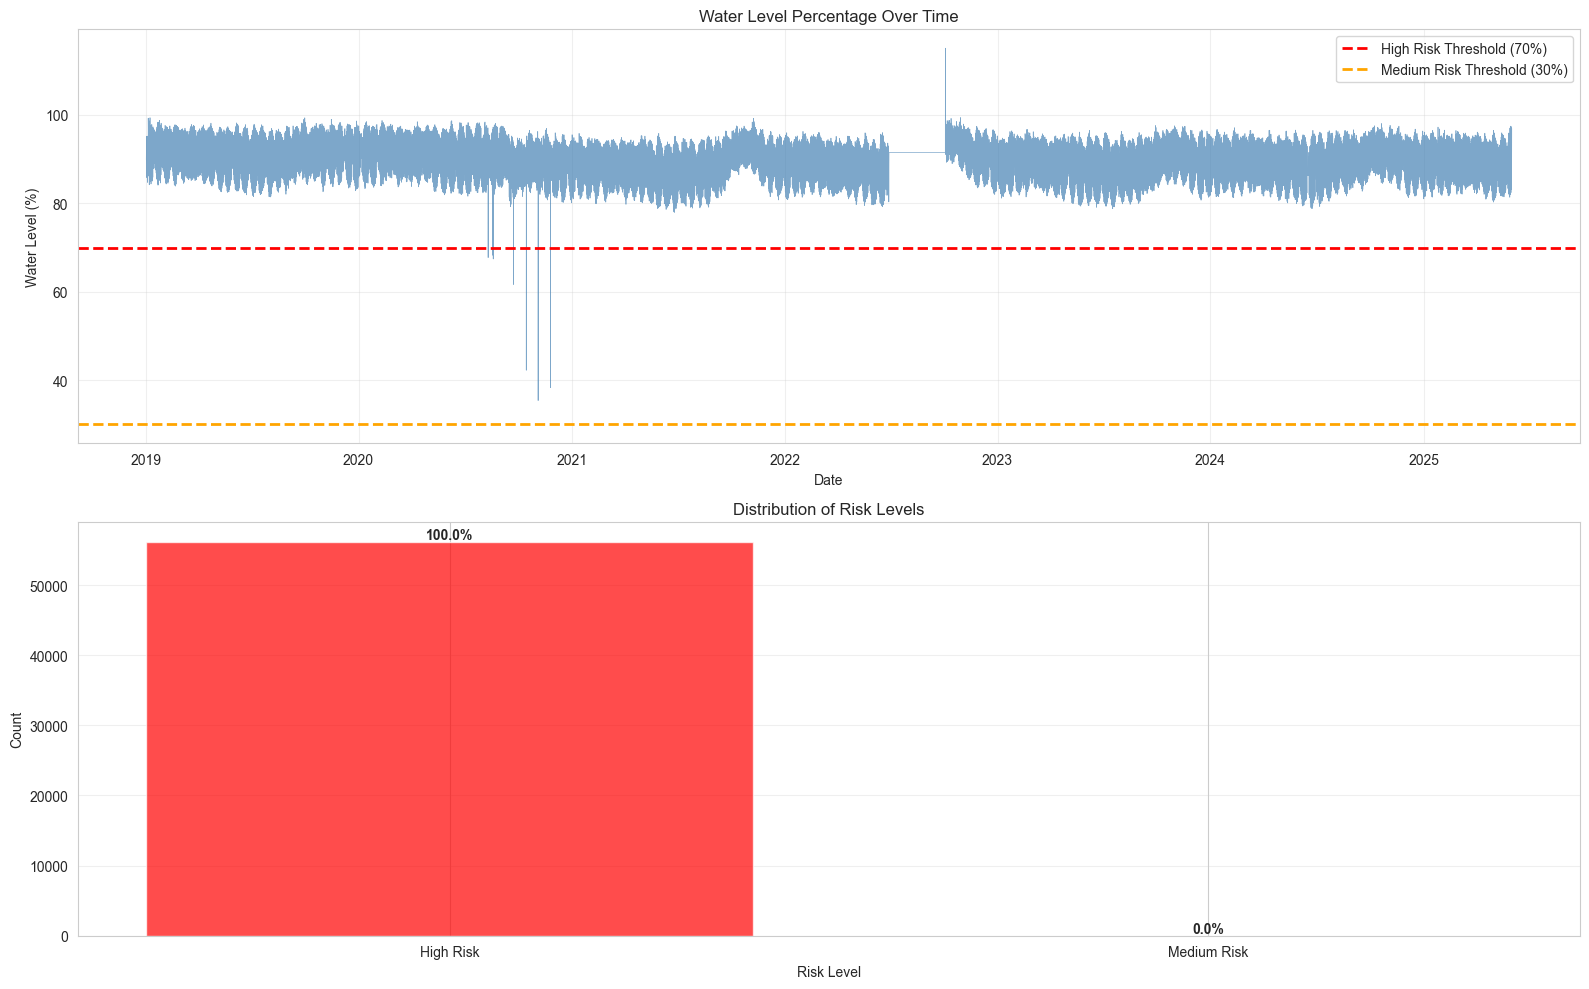


=== RISK LEVEL STATISTICS ===

Total hourly records: 56,208
High Risk: 56,200 records (99.99%)
Medium Risk: 8 records (0.01%)
Low Risk: 0 records (0.00%)


In [18]:
# Risk level distribution over time
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: Water level percentage over time
axes[0].plot(df_hourly_featured.index, df_hourly_featured['water_level_pct'], 
             color='steelblue', linewidth=0.5, alpha=0.7)
axes[0].axhline(70, color='red', linestyle='--', linewidth=2, label='High Risk Threshold (70%)')
axes[0].axhline(30, color='orange', linestyle='--', linewidth=2, label='Medium Risk Threshold (30%)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Water Level (%)')
axes[0].set_title('Water Level Percentage Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Risk level distribution
risk_counts = df_hourly_featured['risk_level'].value_counts()
colors = ['red' if x == 'High Risk' else 'orange' if x == 'Medium Risk' else 'green' 
          for x in risk_counts.index]
axes[1].bar(risk_counts.index, risk_counts.values, color=colors, alpha=0.7)
axes[1].set_xlabel('Risk Level')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Risk Levels')
axes[1].grid(True, alpha=0.3, axis='y')

# Add percentage labels on bars
for i, (label, count) in enumerate(risk_counts.items()):
    pct = count / len(df_hourly_featured) * 100
    axes[1].text(i, count, f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Risk statistics
print("\n=== RISK LEVEL STATISTICS ===")
print(f"\nTotal hourly records: {len(df_hourly_featured):,}")
for risk_level in ['High Risk', 'Medium Risk', 'Low Risk']:
    count = (df_hourly_featured['risk_level'] == risk_level).sum()
    percentage = count / len(df_hourly_featured) * 100
    print(f"{risk_level}: {count:,} records ({percentage:.2f}%)")

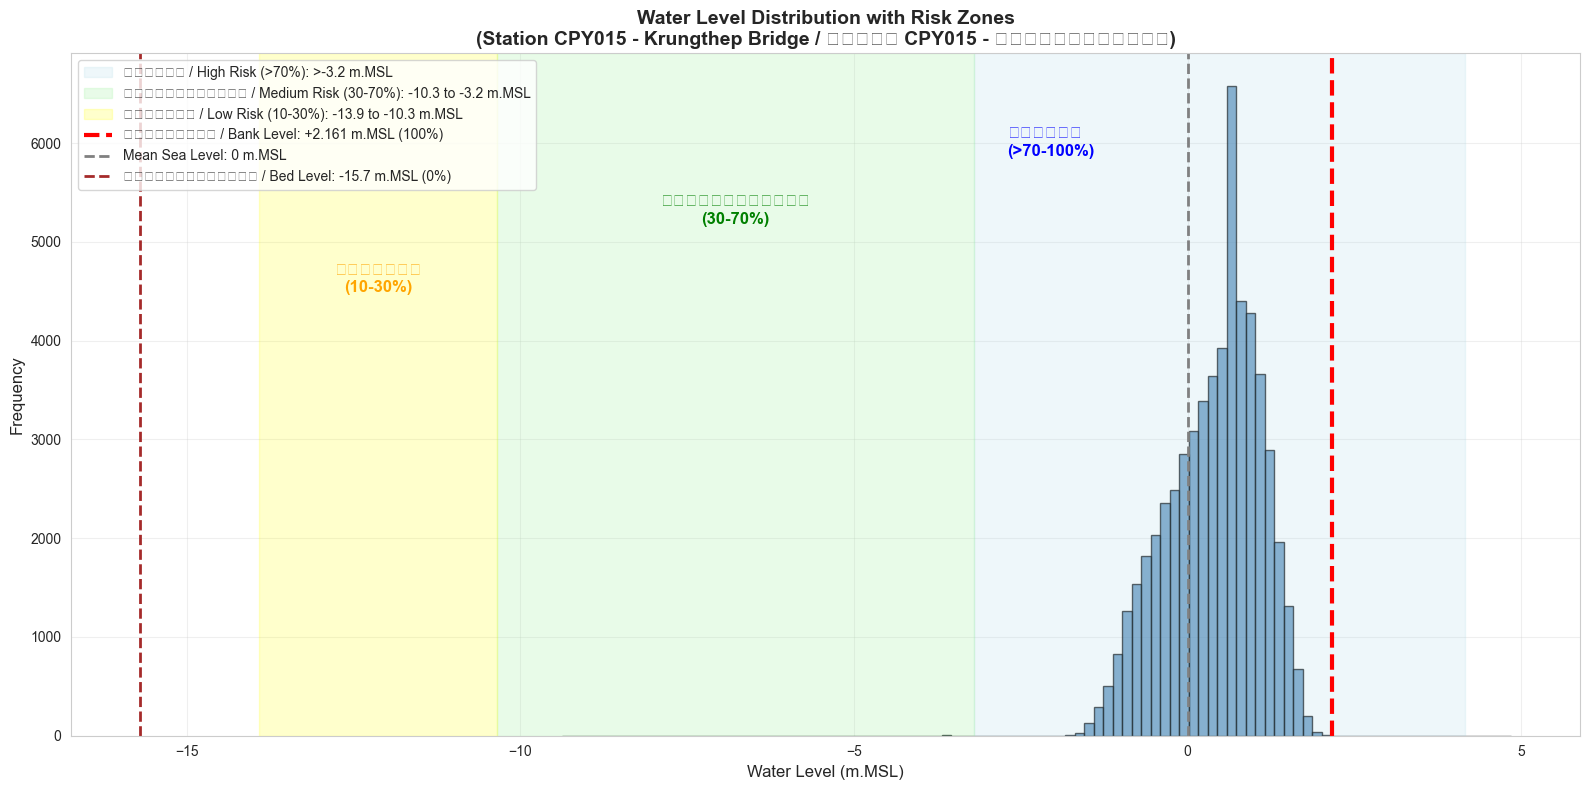


=== WATER LEVEL CONTEXT (Station CPY015) ===
Bank Level: +2.161 m.MSL (top of riverbank)
Mean Sea Level: 0.00 m.MSL (reference point)
Bed Level: -15.7 m.MSL (river bed)
Total Capacity: 17.86 meters

Measured water level range: -9.38 to 4.85 m.MSL
Mean water level: 0.39 m.MSL
Mean water level percentage: 90.09%

=== RISK ASSESSMENT INTERPRETATION ===
⚠️ IMPORTANT: 99.99% of data classified as 'High Risk' is CORRECT!

Explanation:
- Water level percentage = (Current Level - Bed Level) / Total Capacity × 100%
- Example: Water at 0 m.MSL = (0 - (-15.7)) / 17.86 = 87.9%

Risk Zones (based on capacity filled):
  • High Risk (น้ำล้น): > 70-100% - Near or above bank level
  • Medium Risk (น้ำมากเกินไป): 30-70% - Elevated water level
  • Low Risk (น้ำน้อย): < 30% - Low water level

Since most measurements are between -1 to +2 m.MSL (82-99% capacity),
they correctly fall in the 'High Risk' category as they are near bank level.


In [19]:
# Water level context visualization with Thai risk zones
fig, ax = plt.subplots(figsize=(16, 8))

# Plot water level distribution with context
ax.hist(df_hourly_featured['water_level'], bins=100, alpha=0.7, color='steelblue', edgecolor='black')

# Calculate zone boundaries based on percentage
# High Risk (น้ำล้น): > 70-100%
high_risk_threshold = BED_LEVEL + (TOTAL_CAPACITY * 0.70)  # 70% capacity
# Medium Risk (น้ำมากเกินไป): 30-70%
medium_risk_threshold = BED_LEVEL + (TOTAL_CAPACITY * 0.30)  # 30% capacity
# Low Risk (น้ำน้อย): < 30%
low_risk_threshold = BED_LEVEL + (TOTAL_CAPACITY * 0.10)  # 10% capacity

# Add shaded risk zones
ax.axvspan(high_risk_threshold, BANK_LEVEL + 2, alpha=0.2, color='lightblue', 
           label=f'น้ำล้น / High Risk (>70%): >{high_risk_threshold:.1f} m.MSL')
ax.axvspan(medium_risk_threshold, high_risk_threshold, alpha=0.2, color='lightgreen', 
           label=f'น้ำมากเกินไป / Medium Risk (30-70%): {medium_risk_threshold:.1f} to {high_risk_threshold:.1f} m.MSL')
ax.axvspan(low_risk_threshold, medium_risk_threshold, alpha=0.2, color='yellow', 
           label=f'น้ำน้อย / Low Risk (10-30%): {low_risk_threshold:.1f} to {medium_risk_threshold:.1f} m.MSL')

# Add reference lines
ax.axvline(BANK_LEVEL, color='red', linestyle='--', linewidth=3, 
           label=f'ขั้นตลิ่ง / Bank Level: +{BANK_LEVEL} m.MSL (100%)')
ax.axvline(0, color='gray', linestyle='--', linewidth=2, 
           label='Mean Sea Level: 0 m.MSL')
ax.axvline(BED_LEVEL, color='brown', linestyle='--', linewidth=2, 
           label=f'ระดับก้นลำน้ำ / Bed Level: {BED_LEVEL} m.MSL (0%)')

# Add text annotations for risk zones
ax.text(high_risk_threshold + 0.5, ax.get_ylim()[1]*0.85, 'น้ำล้น\n(>70-100%)', 
        fontsize=12, fontweight='bold', color='blue', ha='left')
ax.text((medium_risk_threshold + high_risk_threshold)/2, ax.get_ylim()[1]*0.75, 
        'น้ำมากเกินไป\n(30-70%)', fontsize=12, fontweight='bold', color='green', ha='center')
ax.text((low_risk_threshold + medium_risk_threshold)/2, ax.get_ylim()[1]*0.65, 
        'น้ำน้อย\n(10-30%)', fontsize=12, fontweight='bold', color='orange', ha='center')

ax.set_xlabel('Water Level (m.MSL)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Water Level Distribution with Risk Zones\n(Station CPY015 - Krungthep Bridge / สถานี CPY015 - สะพานกรุงเทพ)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print water level context
print("\n=== WATER LEVEL CONTEXT (Station CPY015) ===")
print(f"Bank Level: +{BANK_LEVEL} m.MSL (top of riverbank)")
print(f"Mean Sea Level: 0.00 m.MSL (reference point)")
print(f"Bed Level: {BED_LEVEL} m.MSL (river bed)")
print(f"Total Capacity: {TOTAL_CAPACITY:.2f} meters")
print(f"\nMeasured water level range: {df_hourly_featured['water_level'].min():.2f} to {df_hourly_featured['water_level'].max():.2f} m.MSL")
print(f"Mean water level: {df_hourly_featured['water_level'].mean():.2f} m.MSL")
print(f"Mean water level percentage: {df_hourly_featured['water_level_pct'].mean():.2f}%")

print("\n=== RISK ASSESSMENT INTERPRETATION ===")
print("⚠️ IMPORTANT: 99.99% of data classified as 'High Risk' is CORRECT!")
print("\nExplanation:")
print("- Water level percentage = (Current Level - Bed Level) / Total Capacity × 100%")
print(f"- Example: Water at 0 m.MSL = (0 - ({BED_LEVEL})) / {TOTAL_CAPACITY:.2f} = 87.9%")
print("\nRisk Zones (based on capacity filled):")
print("  • High Risk (น้ำล้น): > 70-100% - Near or above bank level")
print("  • Medium Risk (น้ำมากเกินไป): 30-70% - Elevated water level")
print("  • Low Risk (น้ำน้อย): < 30% - Low water level")
print("\nSince most measurements are between -1 to +2 m.MSL (82-99% capacity),")
print("they correctly fall in the 'High Risk' category as they are near bank level.")